In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Hassan Mahmood\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hassan Mahmood\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~

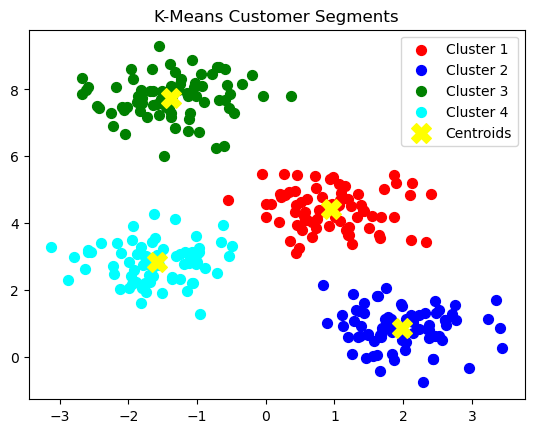

In [2]:

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. INITIALIZE: Tell the algorithm to find 4 groups
# init='k-means++' is a smart trick to pick starting points far apart
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)

# 3. FIT & PREDICT: In unsupervised learning, these happen at the same time
# The model 'learns' the clusters and 'assigns' them to each row
y_kmeans = kmeans.fit_predict(X)

# 4. VISUALIZE: See the 'Groups' the AI found
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')

# Plot the Centroids (The 'Heart' of each cluster)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='yellow', label='Centroids', marker='X')

plt.title('K-Means Customer Segments')
plt.legend()
plt.show()

In [5]:
df = pd.read_csv('StressLevelDataset.csv')

In [6]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [24]:
new_df = df[['anxiety_level', 'sleep_quality']]

In [25]:
new_df.head()

,anxiety_level,sleep_quality
0,14,2
1,15,1
2,12,2
3,16,1
4,16,5


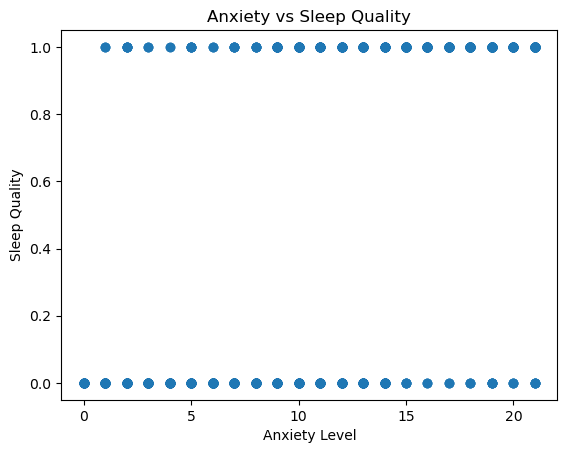

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(new_df['anxiety_level'], new_df['sleep_quality'])
plt.xlabel('Anxiety Level')
plt.ylabel('Sleep Quality')
plt.title('Anxiety vs Sleep Quality')
plt.show()


In [11]:
from sklearn.cluster import KMeans

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit_predict(new_df)
    wcss.append(kmeans.inertia_)

c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

In [13]:
wcss

[43764.38545454544,
 12838.440697998698,
 5949.31274721561,
 3966.0543736771265,
 2973.7242088164408,
 2349.2936190644464,
 1967.398306974384,
 1695.8678801725484,
 1500.9500633388395,
 1339.7757113330972]

Text(0.5, 0, 'Number of clusters')

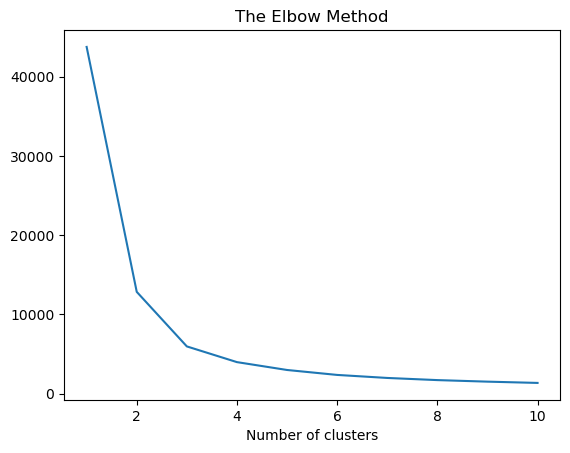

In [15]:
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')


In [29]:
x = df.iloc[:,:].values
km = KMeans(n_clusters=4, init='k-means++', random_state=0)
y_means = km.fit_predict(x)

c:\Users\Hassan Mahmood\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [18]:
y_means.shape

(1100,)

In [19]:
x

array([[14, 20,  0, ...,  3,  2,  1],
       [15,  8,  1, ...,  5,  5,  2],
       [12, 18,  1, ...,  2,  2,  1],
       ...,
       [ 4, 26,  0, ...,  2,  1,  0],
       [21,  0,  1, ...,  4,  4,  2],
       [18,  6,  1, ...,  1,  4,  2]])

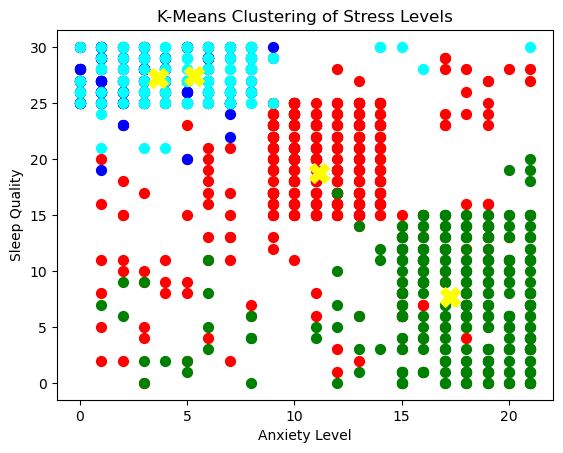

In [31]:
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], 
            s=200, c='yellow', label='Centroids', marker='X')
plt.title('K-Means Clustering of Stress Levels')
plt.xlabel('Anxiety Level')
plt.ylabel('Sleep Quality')
plt.show()
